# Lab 1: Getting Started with a Simple Image Object Detection Pipeline


In [ ]:
!pip install ultralytics matplotlib opencv-python-headless pillow requests -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import requests
from io import BytesIO

print("✅ Toutes les bibliothèques sont importées avec succès !")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Toutes les bibliothèques sont importées avec succès !


In [ ]:
model = YOLO("yolov8n.pt")

print("✅ Modèle YOLOv8n chargé !")
print("Classes apprises par le modèle :")
print(model.names)

✅ Modèle YOLOv8n chargé !
Classes apprises par le modèle :
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


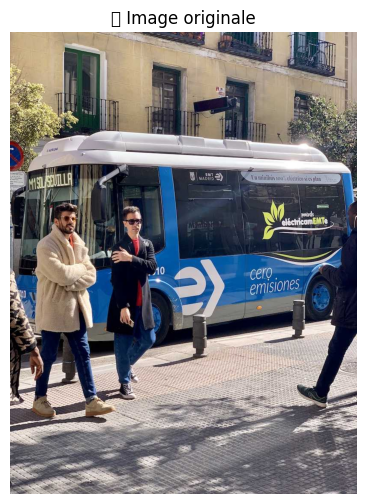

In [ ]:
image_url = "https://ultralytics.com/images/bus.jpg"

response = requests.get(image_url)
image = Image.open(BytesIO(response.content))

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.title("🖼️ Image originale")
plt.show()

In [ ]:
results = model(image_url, conf=0.25, iou=0.45)

print("✅ Détection terminée !")
print(f"Nombre d'objets détectés : {len(results[0].boxes)}")



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 355.8ms
Speed: 20.0ms preprocess, 355.8ms inference, 44.8ms postprocess per image at shape (1, 3, 640, 480)
✅ Détection terminée !
Nombre d'objets détectés : 6


In [ ]:
print(results[0].boxes.data)


tensor([[2.2871e+01, 2.3128e+02, 8.0500e+02, 7.5684e+02, 8.7345e-01, 5.0000e+00],
        [4.8550e+01, 3.9855e+02, 2.4535e+02, 9.0270e+02, 8.6569e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7704e+02, 8.5284e-01, 0.0000e+00],
        [2.2152e+02, 4.0580e+02, 3.4497e+02, 8.5754e+02, 8.2522e-01, 0.0000e+00],
        [0.0000e+00, 5.5053e+02, 6.3007e+01, 8.7344e+02, 2.6111e-01, 0.0000e+00],
        [5.8171e-02, 2.5446e+02, 3.2557e+01, 3.2487e+02, 2.5507e-01, 1.1000e+01]])


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


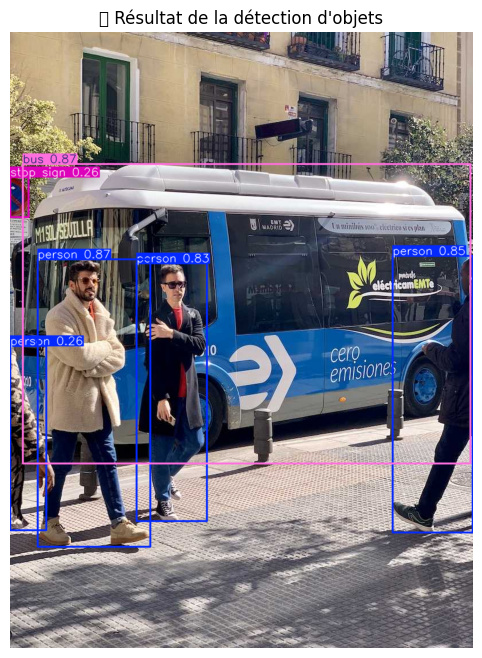

📁 Image sauvegardée sous 'detection_result.jpg'


In [ ]:
result_img = results[0].plot(line_width=2, font_size=12)

result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(result_img_rgb)
plt.axis("off")
plt.title("🚀 Résultat de la détection d'objets")
plt.show()

cv2.imwrite("detection_result.jpg", result_img)
print("📁 Image sauvegardée sous 'detection_result.jpg'")

In [ ]:
results_low_conf = model(image_url, conf=0.10, iou=0.45)
print(f"Nombre d'objets détectés avec conf=0.10 : {len(results_low_conf[0].boxes)}")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 176.2ms
Speed: 5.4ms preprocess, 176.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Nombre d'objets détectés avec conf=0.10 : 6


In [ ]:
model_m = YOLO("yolov8m.pt")
results_m = model_m(image_url, conf=0.10, iou=0.45)

print(f"Nombre d'objets détectés avec yolov8m : {len(results_m[0].boxes)}")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 tie, 1067.1ms
Speed: 4.5ms preprocess, 1067.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Nombre d'objets détectés avec yolov8m : 6


In [ ]:
boxes = results[0].boxes
classes = boxes.cls

print("Classes détectées :", classes)

Classes détectées : tensor([ 5.,  0.,  0.,  0.,  0., 11.])
